In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from datetime import datetime, timedelta

# Carrega episódios da OMDb
episodios = pd.read_csv('../data/processed/episodios_omdb.csv')

# Converte data_estreia para o tipo datetime
episodios['data_estreia'] = pd.to_datetime(episodios['data_estreia'], format='%d %b %Y')

print(episodios[['titulo', 'data_estreia', 'rating_imdb']].head(10))

                                           titulo data_estreia  rating_imdb
0            The One Where Monica Gets a Roommate   1994-09-22          8.1
1            The One with the Sonogram at the End   1994-09-29          7.9
2                          The One with the Thumb   1994-10-06          8.0
3              The One with George Stephanopoulos   1994-10-13          7.9
4  The One with the East German Laundry Detergent   1994-10-20          8.3
5                           The One with the Butt   1994-10-27          8.0
6                       The One with the Blackout   1994-11-03          8.9
7                   The One Where Nana Dies Twice   1994-11-10          7.9
8                The One Where Underdog Gets Away   1994-11-17          8.1
9                         The One with the Monkey   1994-12-15          7.9


In [2]:
# Feriados americanos de 1994 a 2004 (período da série)
feriados_americanos = {}
for ano in range(1994, 2005):
    feriados_americanos.update(holidays.US(years=ano))

# Além dos feriados oficiais, adiciona datas comemorativas
# que não são feriado oficial mas são culturalmente relevantes
datas_especiais = []

for ano in range(1994, 2005):
    datas_especiais.extend([
        datetime(ano, 10, 31),  # Halloween
        datetime(ano, 2, 14),   # Dia dos Namorados
        datetime(ano, 12, 31),  # Réveillon
    ])

print(f"Total de feriados oficiais mapeados: {len(feriados_americanos)}")
print(f"Total de datas especiais adicionais: {len(datas_especiais)}")

Total de feriados oficiais mapeados: 122
Total de datas especiais adicionais: 33


In [3]:
def eh_proximo_de_feriado(data, janela_dias=7):
    """
    Verifica se uma data está dentro de X dias de um feriado.
    janela_dias=7 significa: até 7 dias antes ou depois do feriado.
    Retorna o nome do feriado se encontrar, ou None se não encontrar.
    """
    for i in range(-janela_dias, janela_dias + 1):
        data_verificar = data + timedelta(days=i)
        
        # Verifica feriados oficiais
        if data_verificar.date() in feriados_americanos:
            return feriados_americanos[data_verificar.date()]
        
        # Verifica datas especiais
        for data_especial in datas_especiais:
            if (data_verificar.month == data_especial.month and 
                data_verificar.day == data_especial.day):
                mapa_nomes = {
                    10: 'Halloween',
                    2:  'Valentine\'s Day',
                    12: 'New Year\'s Eve' if data_especial.day == 31 else None
                }
                return mapa_nomes.get(data_especial.month)
    
    return None  # Não é próximo de nenhum feriado

# Testa a função com o primeiro episódio
print(eh_proximo_de_feriado(episodios['data_estreia'].iloc[0]))

None


In [4]:
# Aplica a função em cada linha do DataFrame
episodios['feriado_proximo'] = episodios['data_estreia'].apply(eh_proximo_de_feriado)

# Cria coluna booleana — True se for próximo de feriado
episodios['eh_feriado'] = episodios['feriado_proximo'].notna()

# Quantos episódios são próximos de feriados?
print(f"Episódios próximos de feriados: {episodios['eh_feriado'].sum()}")
print(f"Episódios normais: {(~episodios['eh_feriado']).sum()}")

# Quais feriados aparecem?
print("\nFeriados encontrados:")
print(episodios[episodios['eh_feriado']]['feriado_proximo'].value_counts())

Episódios próximos de feriados: 103
Episódios normais: 132

Feriados encontrados:
feriado_proximo
Columbus Day                  19
Halloween                     18
Valentine's Day               18
Veterans Day                  11
Martin Luther King Jr. Day    11
Thanksgiving Day               9
Washington's Birthday          5
New Year's Eve                 4
Veterans Day (observed)        4
New Year's Day                 2
Christmas Day                  1
New Year's Day (observed)      1
Name: count, dtype: int64


In [5]:
# Rating médio de episódios de feriado vs normais
comparacao = episodios.groupby('eh_feriado')['rating_imdb'].agg(['mean', 'count', 'std']).reset_index()
comparacao.columns = ['eh_feriado', 'rating_medio', 'quantidade', 'desvio_padrao']
comparacao['eh_feriado'] = comparacao['eh_feriado'].map({True: 'Próximo de feriado', False: 'Episódio normal'})
comparacao['rating_medio'] = comparacao['rating_medio'].round(2)

print(comparacao)

           eh_feriado  rating_medio  quantidade  desvio_padrao
0     Episódio normal          8.25         102       0.484563
1  Próximo de feriado          8.32          87       0.414244


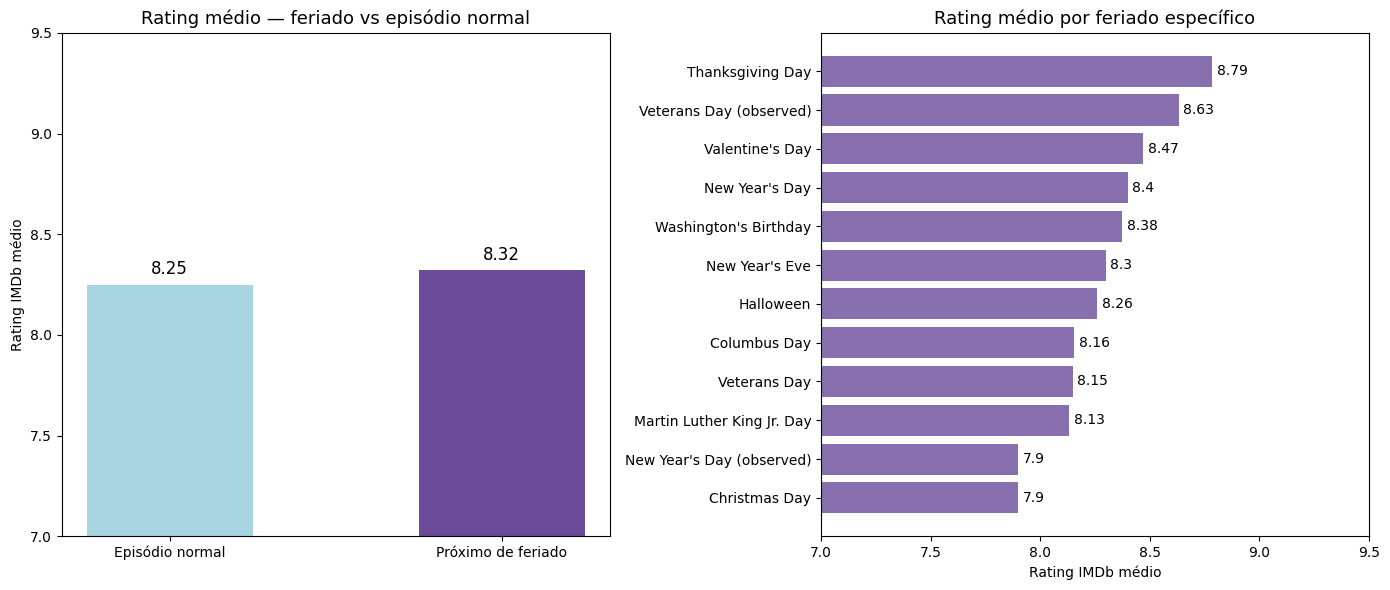

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

cores = ['#A8D5E2', '#6B4C9A']

# Gráfico 1 — Rating médio comparativo
categorias = comparacao['eh_feriado']
ratings = comparacao['rating_medio']

bars = ax1.bar(categorias, ratings, color=cores, width=0.5)
ax1.set_title('Rating médio — feriado vs episódio normal', fontsize=13)
ax1.set_ylabel('Rating IMDb médio')
ax1.set_ylim(7, 9.5)

for bar, rating in zip(bars, ratings):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             str(rating), ha='center', fontsize=12)

# Gráfico 2 — Rating por feriado específico
episodios_feriado = episodios[episodios['eh_feriado']].copy()
rating_por_feriado = episodios_feriado.groupby('feriado_proximo')['rating_imdb'].mean().sort_values(ascending=True)

ax2.barh(rating_por_feriado.index, rating_por_feriado.values, color='#6B4C9A', alpha=0.8)
ax2.set_title('Rating médio por feriado específico', fontsize=13)
ax2.set_xlabel('Rating IMDb médio')
ax2.set_xlim(7, 9.5)

for i, v in enumerate(rating_por_feriado.values):
    ax2.text(v + 0.02, i, str(round(v, 2)), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/feriados_vs_rating.png', dpi=150)
plt.show()